# Intermediate-Lens Drive Design Notebook (IL1/IL2/IL3)

This notebook is a parameter-driven design tool.

You choose:
- current full-scale `I_fs` (A)
- turns (to convert to ampere-turns)
- accelerating voltage (to compute `Rc`)
- geometry constants `Gc`
- column distances (`d_obj_to_il1`, `d_il1_to_il2`, `d_il2_to_il3`, `d_il3_to_image`)
- objective and projector magnification (`M_obj`, `M_proj`)
- target system magnifications

Then it solves how to drive **IL1, IL2, IL3** to hit each requested magnification while keeping total image rotation constant.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.constants import e, m_e, c, mu_0

from temgym_core.transfer_matrices import propagation_matrix, lens_matrix


def compute_Rc_from_voltage(U_accel_V: float) -> float:
    """Rotation constant Rc [rad/AT] from accelerating voltage [V]."""
    if U_accel_V <= 0.0:
        raise ValueError("U_accel_V must be > 0")
    gamma_rel = 1.0 + e * U_accel_V / (m_e * c**2)
    v = c * np.sqrt(1.0 - 1.0 / gamma_rel**2)
    return float(e * mu_0 / (2.0 * m_e * v))


## 1) User Inputs

Edit this cell first.


In [12]:
# -----------------------------
# Magnification targets
# -----------------------------
M_obj = 80.0
M_proj = 100.0

target_system_mags = np.array([
    30000,
    50000,
    100000,
    300000,
    600000,
], dtype=float)

# -----------------------------
# Geometry (meters)
# -----------------------------
# Use d_obj_to_il1 > 0 if you want IL1 (f1) to be observable in this reduced model.
geometry = {
    "d_obj_to_il1": 10e-3,
    "d_il1_to_il2": 52e-3,
    "d_il2_to_il3": 62e-3,
    "d_il3_to_image": 48.75e-3,
}

# -----------------------------
# Lens electrical / physical constants
# -----------------------------
I_fs_A = 2.0  # full-scale current for normalized drive I_norm in [0,1]

turns = {
    "IL1": 3000,
    "IL2": 2000,
    "IL3": 2000,
}

# Physical geometry constants [1 / (AT^2 * m)]
Gc_phys = {
    "IL1": 8.0e-6,
    "IL2": 8.0e-6,
    "IL3": 8.0e-6,
}

# Voltage -> Rc physical [rad / AT]
U_accel_V = 200e3
Rc_phys = float(compute_Rc_from_voltage(U_accel_V))

# -----------------------------
# Rotation target definition
# -----------------------------
invert_image = True  # signed A = -M_IL when True

# Reference normalized currents used to define constant total rotation.
reference_i_norm = {
    "IL1": 0.9,
    "IL2": 0.9,
    "IL3": 0.9,
}

# -----------------------------
# Derived effective constants (for normalized current model)
# -----------------------------
Gc_eff = {
    k: Gc_phys[k] * (turns[k] * I_fs_A) ** 2 for k in ("IL1", "IL2", "IL3")
}
Rc_eff = {
    k: Rc_phys * (turns[k] * I_fs_A) for k in ("IL1", "IL2", "IL3")
}

theta_target = float(
    Rc_eff["IL1"] * reference_i_norm["IL1"]
    + Rc_eff["IL2"] * reference_i_norm["IL2"]
    + Rc_eff["IL3"] * reference_i_norm["IL3"]
)

M_il_targets = target_system_mags / (M_obj * M_proj)

print("Configured targets:")
print("  M_system:", target_system_mags.astype(int).tolist())
print("  M_IL:", np.round(M_il_targets, 6).tolist())
print()
print("Geometry [mm]:")
for k, v in geometry.items():
    print(f"  {k:15s} = {v*1e3:8.3f}")
print()
print(f"Voltage: {U_accel_V/1e3:.1f} kV")
print(f"Rc_phys: {Rc_phys:.6e} rad/AT")
print("Gc_eff [1/m]:", {k: round(v, 4) for k, v in Gc_eff.items()})
print("Rc_eff [rad]:", {k: round(v, 4) for k, v in Rc_eff.items()})
print(f"theta_target: {theta_target:.6f} rad ({np.rad2deg(theta_target):.3f} deg)")


Configured targets:
  M_system: [30000, 50000, 100000, 300000, 600000]
  M_IL: [3.75, 6.25, 12.5, 37.5, 75.0]

Geometry [mm]:
  d_obj_to_il1    =   10.000
  d_il1_to_il2    =   52.000
  d_il2_to_il3    =   62.000
  d_il3_to_image  =   48.750

Voltage: 200.0 kV
Rc_phys: 5.301506e-04 rad/AT
Gc_eff [1/m]: {'IL1': 288.0, 'IL2': 128.0, 'IL3': 128.0}
Rc_eff [rad]: {'IL1': 3.1809, 'IL2': 2.1206, 'IL3': 2.1206}
theta_target: 6.679898 rad (382.730 deg)


## 2) Equations Being Solved

For signed relay magnification `A` (typically `A = -M_IL` for inverted imaging), define:
- `d01 = d_obj_to_il1`
- `d12 = d_il1_to_il2`
- `d23 = d_il2_to_il3`
- `d3i = d_il3_to_image`

Using the paraxial thin-lens model with focus constraint (`B = 0`), we express `f1` and `f2` from one free variable `f3`:

- `f2(f3; A) = d12 * (f3*(d23 + d3i) - d23*d3i) / (f3*(A*d01 + d23 + d3i + d12) - d3i*(d23 + d12))`
- `f1(f3; A) = (A*d01*d12*f3) / (f3*(A*(d01 + d12) + d23 + d3i) - d23*d3i)`

Currents and rotation:
- `I_i = sqrt(1/(Gc_eff_i * f_i))`
- `theta_i = Rc_eff_i * I_i`

One scalar root solve per target magnification:

`Rc1*I1(f3) + Rc2*I2(f3) + Rc3*I3(f3) = theta_target`

After solving `f3`, everything else (`f1`, `f2`, `I1`, `I2`, `I3`) follows analytically.


In [13]:
# Matrix helpers for verification
P = lambda d: propagation_matrix(float(d), xp=np)
L = lambda f: lens_matrix(float(f), xp=np)

def system_matrix_from_focals(f1, f2, f3, geom):
    return (
        P(geom["d_il3_to_image"]) @ L(f3) @ P(geom["d_il2_to_il3"]) @ L(f2)
        @ P(geom["d_il1_to_il2"]) @ L(f1) @ P(geom["d_obj_to_il1"])
    )


def f2_from_f3_A(f3, A, geom):
    d01 = geom["d_obj_to_il1"]
    d12 = geom["d_il1_to_il2"]
    d23 = geom["d_il2_to_il3"]
    d3i = geom["d_il3_to_image"]
    num = d12 * (f3 * (d23 + d3i) - d23 * d3i)
    den = f3 * (A * d01 + d23 + d3i + d12) - d3i * (d23 + d12)
    return np.nan if abs(den) < 1e-15 else num / den


def f1_from_f3_A(f3, A, geom):
    d01 = geom["d_obj_to_il1"]
    d12 = geom["d_il1_to_il2"]
    d23 = geom["d_il2_to_il3"]
    d3i = geom["d_il3_to_image"]
    num = A * d01 * d12 * f3
    den = f3 * (A * (d01 + d12) + d23 + d3i) - d23 * d3i
    return np.nan if abs(den) < 1e-15 else num / den


def current_from_focal(f, gc_eff):
    if (not np.isfinite(f)) or f <= 0.0:
        return np.nan
    return float(np.sqrt(1.0 / (gc_eff * f)))


def theta_residual_f3(f3, A, theta_target, geom, gc_eff, rc_eff):
    f2 = f2_from_f3_A(f3, A, geom)
    f1 = f1_from_f3_A(f3, A, geom)
    if not np.all(np.isfinite([f1, f2])) or min(f1, f2, f3) <= 0.0:
        return np.nan

    i1 = current_from_focal(f1, gc_eff["IL1"])
    i2 = current_from_focal(f2, gc_eff["IL2"])
    i3 = current_from_focal(f3, gc_eff["IL3"])
    if not np.all(np.isfinite([i1, i2, i3])):
        return np.nan

    theta = rc_eff["IL1"] * i1 + rc_eff["IL2"] * i2 + rc_eff["IL3"] * i3
    return float(theta - theta_target)


def solve_one_target(m_il, theta_target, geom, gc_eff, rc_eff, invert_image=True,
                     f3_min=1e-3, f3_max=80e-3, n_grid=12000):
    A_target = -float(m_il) if invert_image else float(m_il)

    f3_grid = np.geomspace(f3_min, f3_max, int(n_grid))
    rr = np.array([
        theta_residual_f3(f3, A_target, theta_target, geom, gc_eff, rc_eff)
        for f3 in f3_grid
    ], dtype=float)

    finite = np.isfinite(rr)
    if not np.any(finite):
        raise RuntimeError(f"No finite residuals for M_IL={m_il:.4g}")

    g = f3_grid[finite]
    r = rr[finite]

    bracket = None
    for a, b, ra, rb in zip(g[:-1], g[1:], r[:-1], r[1:]):
        if ra == 0.0:
            f3_star = float(a)
            bracket = (a, a)
            break
        if ra * rb < 0.0:
            bracket = (a, b)
            break
    else:
        f3_star = float(g[np.argmin(np.abs(r))])

    converged = bracket is not None
    if bracket is not None and bracket[0] != bracket[1]:
        f3_star = float(
            brentq(
                lambda x: theta_residual_f3(x, A_target, theta_target, geom, gc_eff, rc_eff),
                bracket[0],
                bracket[1],
                maxiter=200,
            )
        )

    f2_star = float(f2_from_f3_A(f3_star, A_target, geom))
    f1_star = float(f1_from_f3_A(f3_star, A_target, geom))
    if min(f1_star, f2_star, f3_star) <= 0.0 or not np.all(np.isfinite([f1_star, f2_star, f3_star])):
        raise RuntimeError(f"Non-physical solution for M_IL={m_il:.4g}")

    i1 = current_from_focal(f1_star, gc_eff["IL1"])
    i2 = current_from_focal(f2_star, gc_eff["IL2"])
    i3 = current_from_focal(f3_star, gc_eff["IL3"])

    theta_sum = float(rc_eff["IL1"] * i1 + rc_eff["IL2"] * i2 + rc_eff["IL3"] * i3)

    M = system_matrix_from_focals(f1_star, f2_star, f3_star, geom)
    A_actual = float(M[0, 0])
    B_actual = float(M[0, 1])

    return {
        "M_IL": float(m_il),
        "A_target": float(A_target),
        "A_actual": float(A_actual),
        "B_m": float(B_actual),
        "f1_m": float(f1_star),
        "f2_m": float(f2_star),
        "f3_m": float(f3_star),
        "I1_norm": float(i1),
        "I2_norm": float(i2),
        "I3_norm": float(i3),
        "I1_A": float(i1 * I_fs_A),
        "I2_A": float(i2 * I_fs_A),
        "I3_A": float(i3 * I_fs_A),
        "AT1": float(i1 * I_fs_A * turns["IL1"]),
        "AT2": float(i2 * I_fs_A * turns["IL2"]),
        "AT3": float(i3 * I_fs_A * turns["IL3"]),
        "theta_sum": float(theta_sum),
        "theta_err": float(theta_sum - theta_target),
        "converged": bool(converged),
    }


def solve_series(m_il_targets, theta_target, geom, gc_eff, rc_eff, invert_image=True):
    out = []
    for m_il in np.asarray(m_il_targets, dtype=float):
        out.append(
            solve_one_target(
                m_il=m_il,
                theta_target=theta_target,
                geom=geom,
                gc_eff=gc_eff,
                rc_eff=rc_eff,
                invert_image=invert_image,
            )
        )
    return out


## 3) Solve IL1/IL2/IL3 Drives


In [14]:
drive_solution = solve_series(
    m_il_targets=M_il_targets,
    theta_target=theta_target,
    geom=geometry,
    gc_eff=Gc_eff,
    rc_eff=Rc_eff,
    invert_image=invert_image,
)

print(f"Solved points: {len(drive_solution)}")
print(f"Exact root brackets: {sum(int(r['converged']) for r in drive_solution)}/{len(drive_solution)}")
print()

header = (
    f"{'M_sys':>8} | {'M_IL':>7} | {'A_act':>8} | {'B[mm]':>8} | "
    f"{'f1[mm]':>8} | {'f2[mm]':>8} | {'f3[mm]':>8} | "
    f"{'I1':>6} | {'I2':>6} | {'I3':>6} | {'theta_err[deg]':>13}"
)
print(header)
print('-' * len(header))
for m_sys, r in zip(target_system_mags, drive_solution):
    print(
        f"{m_sys:8.0f} | {r['M_IL']:7.3f} | {r['A_actual']:8.3f} | {r['B_m']*1e3:8.4f} | "
        f"{r['f1_m']*1e3:8.3f} | {r['f2_m']*1e3:8.3f} | {r['f3_m']*1e3:8.3f} | "
        f"{r['I1_norm']:6.3f} | {r['I2_norm']:6.3f} | {r['I3_norm']:6.3f} | "
        f"{np.rad2deg(r['theta_err']):13.6f}"
    )

# Lookup table for microscope model
IL_lookup = {
    "control_values_M_IL": np.array([r["M_IL"] for r in drive_solution], dtype=float),
    "control_values_M_system": np.array(target_system_mags, dtype=float),
    "full_scale_current_A": I_fs_A,
    "normalized_currents": np.array(
        [[r["I1_norm"], r["I2_norm"], r["I3_norm"]] for r in drive_solution],
        dtype=float,
    ),
    "currents_A": np.array(
        [[r["I1_A"], r["I2_A"], r["I3_A"]] for r in drive_solution],
        dtype=float,
    ),
    "ampere_turns": np.array(
        [[r["AT1"], r["AT2"], r["AT3"]] for r in drive_solution],
        dtype=float,
    ),
    "lens_names": ["IL1", "IL2", "IL3"],
    "turns": turns,
    "Gc_phys": Gc_phys,
    "Rc_phys": Rc_phys,
    "theta_target": theta_target,
}

print("\nIL_lookup keys:", list(IL_lookup.keys()))
print("normalized_currents shape:", IL_lookup["normalized_currents"].shape)


Solved points: 5
Exact root brackets: 5/5

   M_sys |    M_IL |    A_act |    B[mm] |   f1[mm] |   f2[mm] |   f3[mm] |     I1 |     I2 |     I3 | theta_err[deg]
---------------------------------------------------------------------------------------------------------------------
   30000 |   3.750 |   -3.750 |   0.0000 |    3.410 |   25.125 |    6.714 |  1.009 |  0.558 |  1.079 |     -0.000000
   50000 |   6.250 |   -6.250 |   0.0000 |    3.957 |   25.035 |    5.551 |  0.937 |  0.559 |  1.186 |     -0.000000
  100000 |  12.500 |  -12.500 |   0.0000 |    4.868 |   24.358 |    4.505 |  0.845 |  0.566 |  1.317 |      0.000000
  300000 |  37.500 |  -37.500 |  -0.0000 |    6.453 |   21.351 |    3.743 |  0.734 |  0.605 |  1.445 |      0.000000
  600000 |  75.000 |  -75.000 |  -0.0000 |    7.291 |   17.509 |    3.732 |  0.690 |  0.668 |  1.447 |     -0.000000

IL_lookup keys: ['control_values_M_IL', 'control_values_M_system', 'full_scale_current_A', 'normalized_currents', 'currents_A', 'ampere

## 4) Plots (Log and Linear Views)


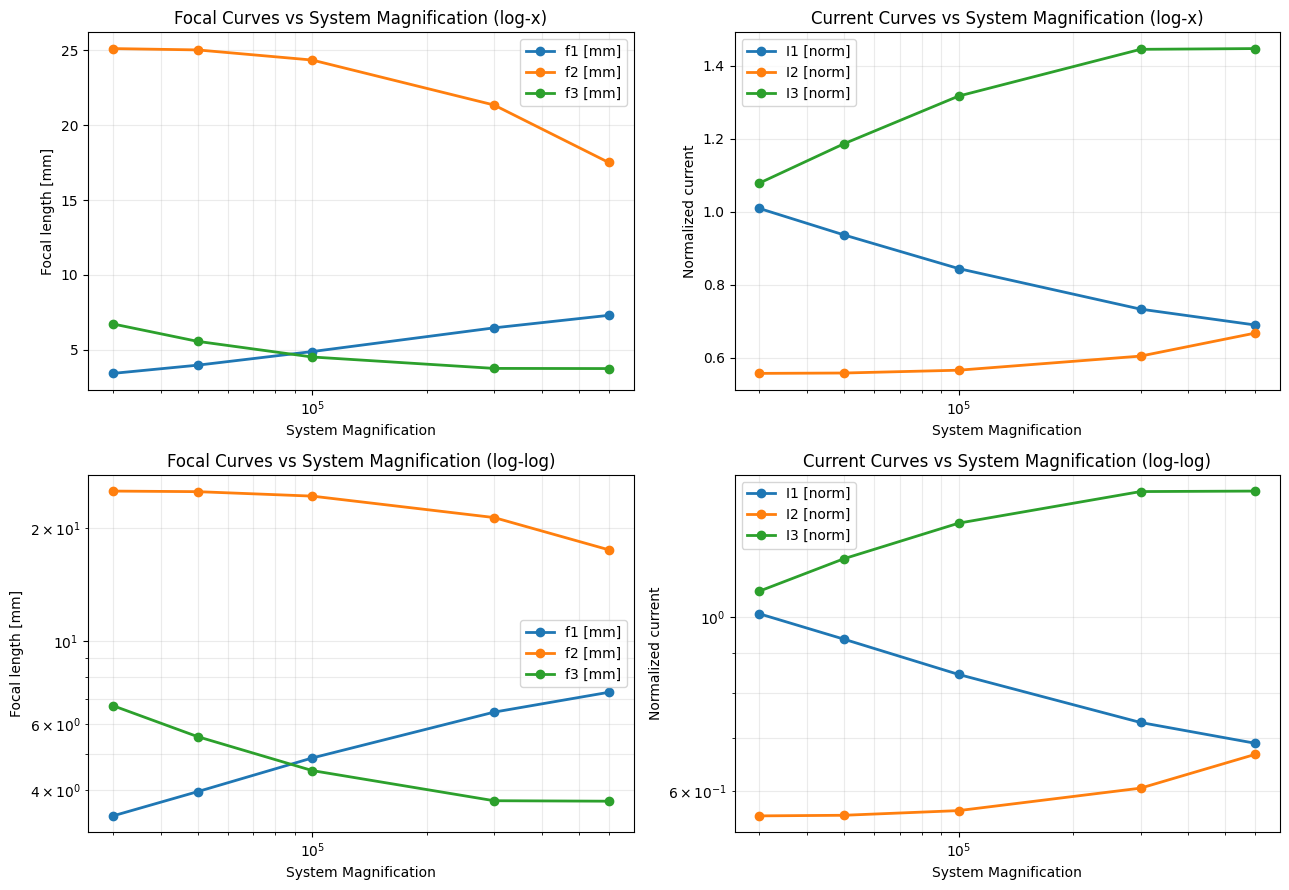

In [15]:
x_sys = np.array(target_system_mags, dtype=float)
x_log = np.log10(x_sys)

f1_mm = np.array([r["f1_m"] for r in drive_solution]) * 1e3
f2_mm = np.array([r["f2_m"] for r in drive_solution]) * 1e3
f3_mm = np.array([r["f3_m"] for r in drive_solution]) * 1e3

I1 = np.array([r["I1_norm"] for r in drive_solution])
I2 = np.array([r["I2_norm"] for r in drive_solution])
I3 = np.array([r["I3_norm"] for r in drive_solution])

fig, axs = plt.subplots(2, 2, figsize=(13, 9))

# semilog-x focals
ax = axs[0, 0]
ax.semilogx(x_sys, f1_mm, 'o-', linewidth=2, label='f1 [mm]')
ax.semilogx(x_sys, f2_mm, 'o-', linewidth=2, label='f2 [mm]')
ax.semilogx(x_sys, f3_mm, 'o-', linewidth=2, label='f3 [mm]')
ax.set_title('Focal Curves vs System Magnification (log-x)')
ax.set_xlabel('System Magnification')
ax.set_ylabel('Focal length [mm]')
ax.grid(True, which='both', alpha=0.25)
ax.legend()

# semilog-x currents
ax = axs[0, 1]
ax.semilogx(x_sys, I1, 'o-', linewidth=2, label='I1 [norm]')
ax.semilogx(x_sys, I2, 'o-', linewidth=2, label='I2 [norm]')
ax.semilogx(x_sys, I3, 'o-', linewidth=2, label='I3 [norm]')
ax.set_title('Current Curves vs System Magnification (log-x)')
ax.set_xlabel('System Magnification')
ax.set_ylabel('Normalized current')
ax.grid(True, which='both', alpha=0.25)
ax.legend()

# log-log focals
ax = axs[1, 0]
ax.loglog(x_sys, f1_mm, 'o-', linewidth=2, label='f1 [mm]')
ax.loglog(x_sys, f2_mm, 'o-', linewidth=2, label='f2 [mm]')
ax.loglog(x_sys, f3_mm, 'o-', linewidth=2, label='f3 [mm]')
ax.set_title('Focal Curves vs System Magnification (log-log)')
ax.set_xlabel('System Magnification')
ax.set_ylabel('Focal length [mm]')
ax.grid(True, which='both', alpha=0.25)
ax.legend()

# log-log currents
ax = axs[1, 1]
ax.loglog(x_sys, I1, 'o-', linewidth=2, label='I1 [norm]')
ax.loglog(x_sys, I2, 'o-', linewidth=2, label='I2 [norm]')
ax.loglog(x_sys, I3, 'o-', linewidth=2, label='I3 [norm]')
ax.set_title('Current Curves vs System Magnification (log-log)')
ax.set_xlabel('System Magnification')
ax.set_ylabel('Normalized current')
ax.grid(True, which='both', alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()
